In [25]:
# =====================================================================
# PASO 1 — Fundación: carga, limpieza y horizonte H  (versión reusable)
# =====================================================================
import os
import pandas as pd
import numpy as np

PATH = 'dataset/'
# --- 1.1 Carga ---
ID_COL   = 'customer_unique_id'
DATE_COL = 'order_purchase_timestamp'
TARGET   = 'is_churn'

orders    = pd.read_csv(os.path.join(PATH, 'olist_orders_dataset.csv')) # Pedidos
customers = pd.read_csv(os.path.join(PATH, 'olist_customers_dataset.csv')) # Clientes
payments  = pd.read_csv(os.path.join(PATH, 'olist_order_payments_dataset.csv')) # Pagos

# --- 1.2 Limpieza (solo entregadas + pagos consolidados por orden) ---
# Ordenes solo con el status de entregado, se convierte en datos de tipo fecha
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
for c in ['order_purchase_timestamp',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']:
    orders_clean[c] = pd.to_datetime(orders_clean[c])

# Se agrupa por ordenes de pagos sumando el valor pagado
pagos_orden = payments.groupby('order_id')['payment_value'].sum().reset_index() # Reset index convierte order_id como indice de la serie resultante

# --- 1.3 Master table a nivel orden (insumo de todo el pipeline) ---
df_master = (orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp',
                           'order_delivered_customer_date', 'order_estimated_delivery_date']]
             .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
             .merge(pagos_orden, on='order_id', how='left'))

print(f"df_master: {df_master.shape[0]:,} órdenes | "
      f"{df_master['customer_unique_id'].nunique():,} clientes únicos")

# --- 1.4 Horizonte H = P90 del intervalo entre recompras ---
# Ordena cronológicamente todo el conjunto de órdenes desde el mas antiguo al mas reciente
# Gaps mide el tiempo de recompra en dias
gaps = (df_master.sort_values('order_purchase_timestamp')
        .groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days) # Calcula la diferencia entre la fecha actual y la fecha de la fila inmediata anterior

# Calcula cuántos días pasaron entre la primera compra de un cliente y su segunda compra (recompra).

# Extrae estadisticamente el percentil 90 quantile(0.90)
gaps = gaps[gaps.notna() & (gaps > 0)]
H = int(gaps.quantile(0.90)) if len(gaps) else 180
print(f"H (P90 entre recompras) = {H} días")
# El 90 porciento de los clientes que recompran, realizan una compra dentro de los sientees 280 días

# Distribución de órdenes por mes (chequeo de volumen real)
print("\nÓrdenes por mes:")
print(df_master['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index())

df_master: 96,478 órdenes | 93,358 clientes únicos
H (P90 entre recompras) = 280 días

Órdenes por mes:
order_purchase_timestamp
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: count, dtype: int64


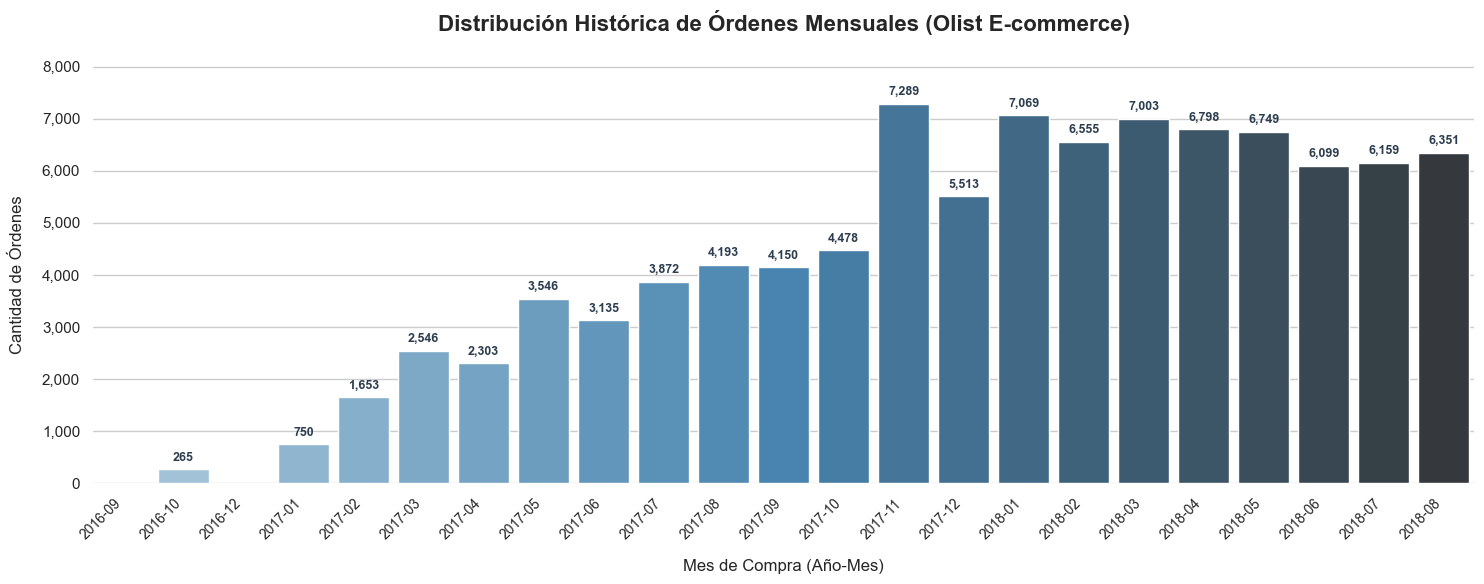

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar la serie de tiempo consolidando las órdenes por mes
ordenes_por_mes = (df_master['order_purchase_timestamp']
                   .dt.to_period('M')
                   .value_counts()
                   .sort_index())

# Convertir el índice a string para evitar conflictos de tipado con Matplotlib
ordenes_por_mes.index = ordenes_por_mes.index.astype(str)

# 2. Configuración estética del gráfico (Estilo Data Science Profesional)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))

# Generamos una paleta degradada basada en el número de barras para pintar directamente
colores = sns.color_palette("Blues_d", n_colors=len(ordenes_por_mes))

# Graficamos forzando un ancho de barra (width) estándar y removiendo 'hue'
sns.barplot(
    x=ordenes_por_mes.index, 
    y=ordenes_por_mes.values, 
    palette=colores,
    ax=ax,
    width=0.85 # Controla el grosor ideal de las barras
)

# 3. Personalización avanzada de etiquetas y títulos
ax.set_title('Distribución Histórica de Órdenes Mensuales (Olist E-commerce)', fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Mes de Compra (Año-Mes)', fontsize=12, labelpad=12)
ax.set_ylabel('Cantidad de Órdenes', fontsize=12, labelpad=12)

# Rotación óptima para evitar solapamiento
ax.set_xticklabels(ordenes_por_mes.index, rotation=45, ha='right', fontsize=10)

# Formatear el eje Y con separadores de miles para legibilidad ejecutiva
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Limitar ligeramente el eje superior para que los Data Labels tengan aire
ax.set_ylim(0, ordenes_por_mes.max() * 1.1)

# 4. Incluir etiquetas de datos sobre cada barra (Data Labels optimizados)
for p in ax.patches:
    height = p.get_height()
    if height > 1: # Filtramos meses ruidosos o vacíos
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    fontsize=9, color='#2c3e50', fontweight='bold',
                    xytext=(0, 4),
                    textcoords='offset points')

sns.despine(left=True, bottom=True) # Removemos bordes innecesarios para un look más moderno
plt.tight_layout()
plt.show()

In [38]:
# =====================================================================
# PASO 2 (parte A) — ESTRUCTURA TEMPORAL ÓPTIMA
# =====================================================================
def construir_target(df, T, H, ventana_actividad=None, id_col=ID_COL, date_col=DATE_COL):
    """
    Foto del mes T.
      - ventana_actividad=None : población = todos los que compraron <= T (acumulativa).
      - ventana_actividad=d    : población objetivo = activos, compraron en (T-d, T].
      - target is_churn = 1 si NO recompra en (T, T+H].
    """
    T   = pd.Timestamp(T)
    obs = df[df[date_col] <= T]
    if ventana_actividad is not None:
        ini = T - pd.Timedelta(days=ventana_actividad)
        poblacion = obs[obs[date_col] > ini][id_col].unique()
    else:
        poblacion = obs[id_col].unique()
    recompra = set(df[(df[date_col] > T) & (df[date_col] <= T + pd.Timedelta(days=H))][id_col])
    out = pd.DataFrame({id_col: poblacion})
    out['mes']      = T.to_period('M').to_timestamp()
    out['is_churn'] = (~out[id_col].isin(recompra)).astype(int)
    return out


def estructura_temporal(df, H, props=(0.55, 0.15, 0.20, 0.10), peso='filas',
                        date_col=DATE_COL, id_col=ID_COL):
    fmin, fmax = df[date_col].min(), df[date_col].max()
    meses = pd.date_range(fmin.to_period('M').to_timestamp(),
                          fmax.to_period('M').to_timestamp(), freq='MS')

    ordenes = (df[date_col].dt.to_period('M').dt.to_timestamp()
                 .value_counts().reindex(meses, fill_value=0).astype(int))
    primera   = df.groupby(id_col)[date_col].min().dt.to_period('M').dt.to_timestamp()
    poblacion = primera.value_counts().reindex(meses, fill_value=0).sort_index().cumsum()
    observable = (meses + pd.to_timedelta(H, 'D')) <= fmax

    # Sera True para todos los meses donde, si sumamos los 120 días de espera ($H$), aún no superamos la fecha máxima del dataset.

    cal = pd.DataFrame({'mes': meses, 'ordenes': ordenes.values,
                        'poblacion': poblacion.values.astype(int),
                        'observable': observable})

    obs = cal.index[cal['observable']].tolist()
    w   = cal.loc[obs, 'poblacion'].to_numpy(float) if peso == 'filas' else np.ones(len(obs))
    wcum  = np.cumsum(w) / w.sum()
    corte = np.cumsum(props)
    rol = pd.Series('Prediccion', index=cal.index)
    for k, idx in enumerate(obs):
        f = wcum[k]
        rol.iloc[idx] = ('Train' if f <= corte[0] else 'Val' if f <= corte[1]
                         else 'BackTest' if f <= corte[2] else 'Live')
    cal['rol'] = rol.values
    return cal

H = 120   # horizonte de churn (4 meses)
estructura = estructura_temporal(df_master, H)
print(estructura.to_string(index=False))
print("\nMeses por rol:", estructura['rol'].value_counts().to_dict())

       mes  ordenes  poblacion  observable        rol
2016-09-01        1          1        True      Train
2016-10-01      265        263        True      Train
2016-11-01        0        263        True      Train
2016-12-01        1        264        True      Train
2017-01-01      750        981        True      Train
2017-02-01     1653       2609        True      Train
2017-03-01     2546       5112        True      Train
2017-04-01     2303       7368        True      Train
2017-05-01     3546      10819        True      Train
2017-06-01     3135      13856        True      Train
2017-07-01     3872      17608        True      Train
2017-08-01     4193      21665        True      Train
2017-09-01     4150      25669        True      Train
2017-10-01     4478      29997        True      Train
2017-11-01     7289      37057        True      Train
2017-12-01     5513      42395        True      Train
2018-01-01     7069      49237        True      Train
2018-02-01     6555      555

=== ARQUITECTURA TEMPORAL DEL PIPELINE (MATRIZ DE CONTROL) ===


Mes Calendario,Órdenes del Mes,Clientes Acumulados,¿Target Observable?,Rol en el Modelo
2016-09,1,1,True,Train
2016-10,265,263,True,Train
2016-11,0,263,True,Train
2016-12,1,264,True,Train
2017-01,750,981,True,Train
2017-02,"1,653","2,609",True,Train
2017-03,"2,546","5,112",True,Train
2017-04,"2,303","7,368",True,Train
2017-05,"3,546","10,819",True,Train
2017-06,"3,135","13,856",True,Train


C:\Users\Percy\AppData\Local\Temp\ipykernel_20556\1887015100.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_grafico['mes_str'], rotation=45, ha='right', fontsize=10, fontweight='bold')


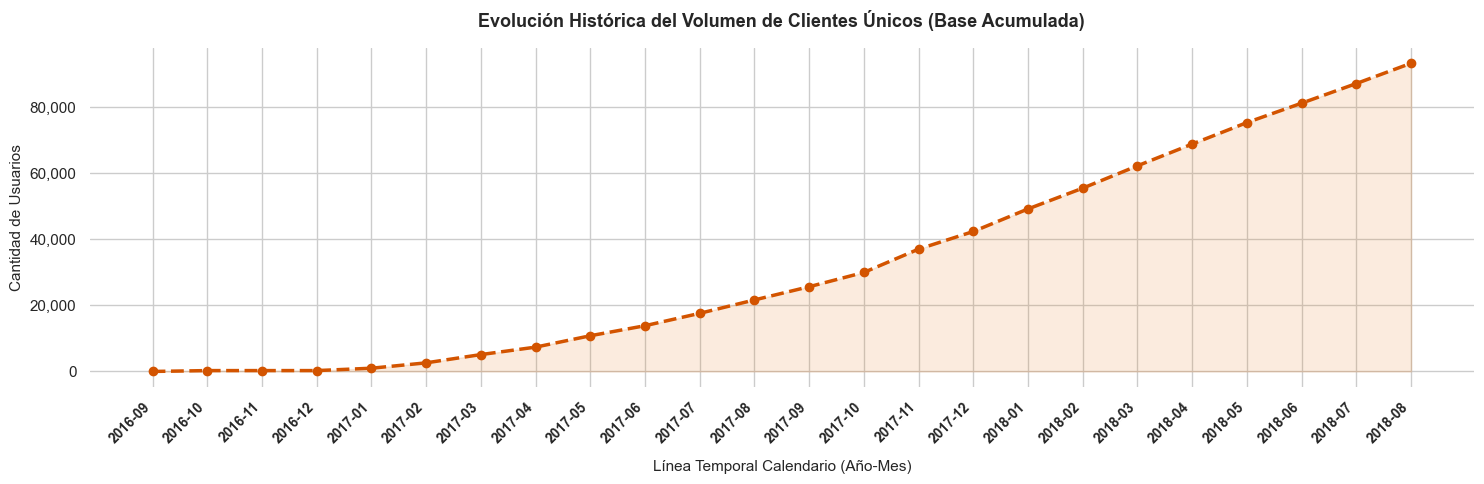

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from IPython.display import display

# =====================================================================
# 1. GENERAR Y MOSTRAR LA TABLA ESTILIZADA DE ROLES (SUPERIOR)
# =====================================================================
tabla_ejecutiva = estructura.copy()
tabla_ejecutiva['mes'] = tabla_ejecutiva['mes'].dt.strftime('%Y-%m')
tabla_ejecutiva.columns = ['Mes Calendario', 'Órdenes del Mes', 'Clientes Acumulados', '¿Target Observable?', 'Rol en el Modelo']

def colorear_rol(valor):
    colores = {
        'Train': 'background-color: #d6e4f0; color: #1e3d59; font-weight: bold;',
        'Val': 'background-color: #f5f0e1; color: #ff6e40; font-weight: bold;',
        'BackTest': 'background-color: #e8f5e9; color: #2e7d32; font-weight: bold;',
        'Live': 'background-color: #e1f5fe; color: #0288d1; font-weight: bold;',
        'Prediccion': 'background-color: #ffebee; color: #c62828; font-weight: bold;'
    }
    return colores.get(valor, '')

tabla_estilizada = (tabla_ejecutiva.style
    .format({'Órdenes del Mes': '{:,}', 'Clientes Acumulados': '{:,}'})
    .set_properties(subset=['Mes Calendario', 'Rol en el Modelo', '¿Target Observable?'], **{'text-align': 'center'})
    .map(colorear_rol, subset=['Rol en el Modelo'])
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px')]}
    ])
    .hide(axis='index')
)

# Forzar a Jupyter a renderizar la tabla HTML limpia arriba
print("=== ARQUITECTURA TEMPORAL DEL PIPELINE (MATRIZ DE CONTROL) ===")
display(tabla_estilizada)
print("\n" + "="*70 + "\n")


# =====================================================================
# 2. GENERAR EL GRÁFICO DE EVOLUCIÓN DE CLIENTES (INFERIOR)
# =====================================================================
df_grafico = estructura.copy().sort_index(ascending=True)
df_grafico['mes_str'] = df_grafico['mes'].dt.strftime('%Y-%m')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 5)) # Ancho completo para una lectura limpia

# Graficar la curva de clientes acumulados alineada en el eje X tradicional
ax.plot(df_grafico['mes_str'], df_grafico['poblacion'], color='#d35400', linestyle='--', marker='o', linewidth=2.5)
ax.fill_between(df_grafico['mes_str'], 0, df_grafico['poblacion'], color='#e67e22', alpha=0.15)

# Personalización del reporte visual
ax.set_title('Evolución Histórica del Volumen de Clientes Únicos (Base Acumulada)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Línea Temporal Calendario (Año-Mes)', fontsize=11, labelpad=10)
ax.set_ylabel('Cantidad de Usuarios', fontsize=11)

# Rotar las fechas del eje X para evitar cualquier tipo de solapamiento
ax.set_xticklabels(df_grafico['mes_str'], rotation=45, ha='right', fontsize=10, fontweight='bold')

# Formatear el eje Y con separadores de miles estándar de Data Science
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Eliminar bordes innecesarios para un estilo moderno y minimalista
sns.despine(left=True, bottom=True, ax=ax)

plt.tight_layout()
plt.show()

In [42]:
# =====================================================================
# PASO 2 (parte B) — POBLACIÓN OBJETIVO Y TARGET (meses modelables)
# =====================================================================
VENTANA = H                                   # población = activos en los últimos H días
meses_modelo = estructura.loc[estructura['rol'] != 'Prediccion', 'mes'].tolist()
panel_target = (pd.concat([construir_target(df_master, T, H, ventana_actividad=VENTANA)
                           for T in meses_modelo], ignore_index=True)
                  .merge(estructura[['mes', 'rol']], on='mes', how='left'))
variables_y  = ['mes', ID_COL, 'is_churn']

print(f"\nFilas del panel (cliente × mes): {len(panel_target):,}")
print(panel_target.groupby('rol')['is_churn'].agg(['mean', 'count']).round(3))


Filas del panel (cliente × mes): 235,875
           mean   count
rol                    
BackTest  0.990   51224
Live      0.990   26874
Train     0.988  134337
Val       0.990   23440


In [3]:
# =====================================================================
# PASO 3A — Tabla de órdenes enriquecida (insumo de la fábrica)
# =====================================================================
items    = pd.read_csv(os.path.join(PATH, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(PATH, 'olist_products_dataset.csv'))
reviews  = pd.read_csv(os.path.join(PATH, 'olist_order_reviews_dataset.csv'))

it = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_ord = it.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),  n_sellers=('seller_id', 'nunique'),
    n_categorias=('product_category_name', 'nunique'),
    price_total=('price', 'sum'),        freight_total=('freight_value', 'sum')).reset_index()
pay_ord = payments.groupby('order_id')['payment_installments'].max().reset_index(name='installments_max')
rev_ord = reviews.groupby('order_id')['review_score'].mean().reset_index()

df_ordenes = (df_master
    .merge(items_ord, on='order_id', how='left')
    .merge(pay_ord,   on='order_id', how='left')
    .merge(rev_ord,   on='order_id', how='left'))
df_ordenes['lead_time']     = (df_ordenes['order_delivered_customer_date'] - df_ordenes['order_purchase_timestamp']).dt.days
df_ordenes['delay']         = (df_ordenes['order_delivered_customer_date'] - df_ordenes['order_estimated_delivery_date']).dt.days
df_ordenes['late']          = (df_ordenes['delay'] > 0).astype(int)
df_ordenes['freight_ratio'] = df_ordenes['freight_total'] / df_ordenes['price_total'].replace(0, np.nan)
df_ordenes['is_weekend']    = (df_ordenes['order_purchase_timestamp'].dt.dayofweek >= 5).astype(int)
print('df_ordenes:', df_ordenes.shape)

df_ordenes: (96478, 19)


In [43]:
# =====================================================================
# PASO 3B — Fábrica de features point-in-time (77 features, sin fuga)
# =====================================================================
def generar_features(df, T, ventana_actividad, id_col=ID_COL, date_col=DATE_COL):
    T = pd.Timestamp(T) # Tiempo, fecha de corte
    h = df[df[date_col] <= T] # SOLO historia <= T
    activos = h[h[date_col] > T - pd.Timedelta(days=ventana_actividad)][id_col].unique()
    h = h[h[id_col].isin(activos)]
    g = h.groupby(id_col)
    f = pd.DataFrame(index=pd.Index(activos, name=id_col))

    # RFM / temporales
    f['recencia']     = (T - g[date_col].max()).dt.days
    f['antiguedad']   = (T - g[date_col].min()).dt.days
    f['frequency']    = g.size()
    f['meses_activo'] = g[date_col].apply(lambda s: s.dt.to_period('M').nunique())
    f['compras_x_mes']= f['frequency'] / ((f['antiguedad'] / 30).clip(lower=1))
    for d in [30, 60, 90, 180]:
        ac = h[h[date_col] > T - pd.Timedelta(days=d)].groupby(id_col).size()
        f[f'ordenes_{d}d'] = ac.reindex(activos).fillna(0).values

    # gaps entre compras
    gp = h.sort_values(date_col).groupby(id_col)[date_col].diff().dt.days
    gp = gp.groupby(h[id_col]).agg(['mean', 'std', 'min', 'max', 'last'])
    for c in ['mean', 'std', 'min', 'max', 'last']:
        f[f'gap_{c}'] = gp[c].reindex(activos).values

    # monetario
    for c in ['sum', 'mean', 'max', 'min', 'std']:
        f[f'monto_{c}'] = g['payment_value'].agg(c).reindex(activos).values
    m90 = h[h[date_col] > T - pd.Timedelta(days=90)].groupby(id_col)['payment_value'].sum()
    f['monto_90d']      = m90.reindex(activos).fillna(0).values
    f['ticket_x_orden'] = f['monto_sum'] / f['frequency']

    # items / sellers / categorías / flete
    for col in ['n_items', 'n_sellers', 'n_categorias', 'price_total', 'freight_total', 'freight_ratio']:
        for st in ['sum', 'mean', 'max']:
            f[f'{col}_{st}'] = g[col].agg(st).reindex(activos).values
    f['cat_distintas'] = g['n_categorias'].max().reindex(activos).values

    # pagos
    f['installments_max']  = g['installments_max'].max().reindex(activos).values
    f['installments_mean'] = g['installments_max'].mean().reindex(activos).values

    # logística
    for c in ['mean', 'max', 'min']:
        f[f'lead_{c}']  = g['lead_time'].agg(c).reindex(activos).values
        f[f'delay_{c}'] = g['delay'].agg(c).reindex(activos).values
    f['late_total'] = g['late'].sum().reindex(activos).values
    f['late_ratio'] = g['late'].mean().reindex(activos).values

    # reviews
    for c in ['mean', 'min', 'max', 'std']:
        f[f'review_{c}'] = g['review_score'].agg(c).reindex(activos).values
    f['reviews_malas']    = h.assign(b=(h['review_score'] <= 2).astype(int)).groupby(id_col)['b'].sum().reindex(activos).values
    f['review_bad_ratio'] = f['reviews_malas'] / f['frequency']

    # comportamiento
    f['weekend_ratio'] = g['is_weekend'].mean().reindex(activos).values

    # =========================================================
    # EXTRA — derivadas para superar 60 features (total = 77)
    # =========================================================
    # hábitos de hora / día
    hh = h.assign(_h=h[date_col].dt.hour, _d=h[date_col].dt.dayofweek)
    f['hora_mean']     = hh.groupby(id_col)['_h'].mean().reindex(activos).values
    f['noche_ratio']   = hh.assign(_n=((hh['_h'] < 6) | (hh['_h'] >= 21)).astype(int)).groupby(id_col)['_n'].mean().reindex(activos).values
    f['dow_distintos'] = hh.groupby(id_col)['_d'].nunique().reindex(activos).values

    # monetario derivado
    f['monto_rango']    = f['monto_max'] - f['monto_min']
    f['monto_cv']       = f['monto_std'] / f['monto_mean'].replace(0, np.nan)
    f['monto_per_item'] = f['monto_sum'] / f['n_items_sum'].replace(0, np.nan)
    f['flete_x_item']   = f['freight_total_sum'] / f['n_items_sum'].replace(0, np.nan)
    f['monto_60d']  = h[h[date_col] > T - pd.Timedelta(days=60)].groupby(id_col)['payment_value'].sum().reindex(activos).fillna(0).values
    f['monto_180d'] = h[h[date_col] > T - pd.Timedelta(days=180)].groupby(id_col)['payment_value'].sum().reindex(activos).fillna(0).values

    # recencia / actividad relativas
    f['recencia_rel']     = f['recencia'] / f['antiguedad'].clip(lower=1)
    f['frac_ordenes_90d'] = f['ordenes_90d'] / f['frequency']
    f['items_x_orden']    = f['n_items_sum'] / f['frequency']
    f['cat_div_ratio']    = f['cat_distintas'] / f['frequency']

    # variabilidad de gaps y logística
    f['gap_rango'] = f['gap_max'] - f['gap_min']
    f['gap_cv']    = f['gap_std'] / f['gap_mean'].replace(0, np.nan)
    f['delay_std'] = g['delay'].std().reindex(activos).values
    f['lead_std']  = g['lead_time'].std().reindex(activos).values

    # reviews y pagos
    f['reviews_buenas']    = h.assign(b=(h['review_score'] >= 4).astype(int)).groupby(id_col)['b'].sum().reindex(activos).values
    f['review_good_ratio'] = f['reviews_buenas'] / f['frequency']
    f['cuotas_uso_ratio']  = h.assign(c=(h['installments_max'] > 1).astype(int)).groupby(id_col)['c'].mean().reindex(activos).values

    # etiqueta del mes (NO es feature)
    f['mes'] = T.to_period('M').to_timestamp()
    return f.reset_index()

In [44]:
# =====================================================================
# PASO 3C — Panel de features + unión con el target  (= Master Table)
# =====================================================================
feat_panel = pd.concat([generar_features(df_ordenes, T, VENTANA) for T in meses_modelo],
                       ignore_index=True)

master = panel_target.merge(feat_panel, on=[ID_COL, 'mes'], how='left')
n_feats = [c for c in master.columns if c not in (variables_y + ['rol'])]
print(f"Master table: {master.shape[0]:,} filas × {len(n_feats)} features")
print("Nulos por feature (top 10):")
print(master[n_feats].isnull().mean().sort_values(ascending=False).head(10).round(3))

Master table: 235,875 filas × 77 features
Nulos por feature (top 10):
gap_cv        0.998
gap_std       0.998
review_std    0.971
gap_min       0.970
gap_mean      0.970
delay_std     0.970
lead_std      0.970
monto_cv      0.970
gap_rango     0.970
monto_std     0.970
dtype: float64


In [45]:
# =====================================================================
# PASO 4 — Master Table:  ya la tienes en `master` (3C). Opcional guardar:
# master.to_parquet(os.path.join(PATH, 'master_table.parquet'))
# =====================================================================

# =====================================================================
# PASO 5 — cleanMT (limpieza reproducible; aprende SOLO en Train)
# =====================================================================
def clean_MT(df, features, params=None):
    """
    Limpia la master table de forma reproducible.
      - inf -> NaN
      - *_std / *_cv -> 0      (un solo valor no tiene dispersión)
      - gap_*        -> antiguedad  (comprador único: su único 'intervalo' es su vida)
      - clip [p01, p99]  (winsorize)   } aprendidos en Train (params)
      - resto de NaN -> mediana         } y reaplicados a Val/BackTest/Live/Predicción
      - agrega flag comprador_unico
    Uso fit:    _, params = clean_MT(master[master.rol=='Train'], feat_cols)
    Uso aplicar: master_clean, _ = clean_MT(master, feat_cols, params=params)
    """
    df  = df.copy()
    fit = params is None
    if fit:
        params = {}

    if 'frequency' in df.columns:
        df['comprador_unico'] = (df['frequency'] <= 1).astype(int)

    df[features] = df[features].replace([np.inf, -np.inf], np.nan)

    disp = [c for c in features if c.endswith('_std') or c.endswith('_cv')]
    df[disp] = df[disp].fillna(0)
    gaps = [c for c in features if c.startswith('gap_')]
    for c in gaps:
        df[c] = df[c].fillna(df['antiguedad'])

    if fit:
        params['clip'] = {c: (df[c].quantile(0.01), df[c].quantile(0.99)) for c in features}
    for c in features:
        lo, hi = params['clip'][c]
        df[c] = df[c].clip(lo, hi)

    if fit:
        params['median'] = df[features].median().to_dict()
    df[features] = df[features].fillna(params['median'])
    return df, params

# --- Aplicación ---
feat_cols = [c for c in master.columns if c not in (variables_y + ['rol'])]

_, clean_params  = clean_MT(master[master['rol'] == 'Train'], feat_cols)   # APRENDE en Train
master_clean, _  = clean_MT(master, feat_cols, params=clean_params)        # APLICA a todo

feat_cols = [c for c in master_clean.columns if c not in (variables_y + ['rol'])]  # +comprador_unico
print(f"master_clean: {master_clean.shape[0]:,} filas × {len(feat_cols)} features")
print("Nulos máximos:", round(master_clean[feat_cols].isnull().mean().max(), 4))
print("% compradores únicos:", round(master_clean['comprador_unico'].mean(), 3))

C:\Users\Percy\AppData\Local\Temp\ipykernel_20556\1336573636.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[features] = df[features].replace([np.inf, -np.inf], np.nan)
C:\Users\Percy\AppData\Local\Temp\ipykernel_20556\1336573636.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[features] = df[features].replace([np.inf, -np.inf], np.nan)


master_clean: 235,875 filas × 78 features
Nulos máximos: 0.0
% compradores únicos: 0.97


In [49]:
# Nueva Celda: Exportar Diccionario de Variables Predictivas a Excel Profesional
import os
import pandas as pd

# 1. Preparar y ordenar todas las variables predictivas
features_ordenadas = sorted(feat_cols)

# 2. Clasificar cada variable en su respectiva familia de negocio
datos_excel = []
for f in features_ordenadas:
    # Determinar la familia
    if f in ['recencia', 'frequency', 'monto_sum'] or f.startswith('monto_'):
        familia = "RFM (Monetaria / Frecuencia / Recencia)"
        descripcion = "Mide qué tan reciente, qué tan seguido y cuánto dinero ha gastado el cliente."
    elif 'time' in f or 'delay' in f or 'late' in f or 'delivered' in f:
        familia = "Logística y Distribución"
        descripcion = "Mide la experiencia de entrega del usuario, tiempos de transporte y retrasos operativos."
    elif f.startswith('gap_') or f == 'antiguedad':
        familia = "Intervalos de Tiempo (Gaps)"
        descripcion = "Analiza los días transcurridos entre compras sucesivas y la vida total del cliente."
    elif f.endswith('_std') or f.endswith('_cv') or f.endswith('_max') or f.endswith('_mean'):
        familia = "Comportamiento Estadístico Histórico"
        descripcion = "Agregaciones avanzadas que capturan la variabilidad y picos en la conducta del consumidor."
    else:
        familia = "Operativa / Inyectada por Pipeline"
        descripcion = "Flags lógicos e indicadores especiales de control (ej. comprador_unico)."
        
    # Guardar la información de la fila
    datos_excel.append({
        'Nombre de la Feature': f,
        'Familia de Negocio': familia,
        'Descripción Analítica (Sugerida)': descripcion
    })

# 3. Crear el DataFrame definitivo para el reporte
df_diccionario = pd.DataFrame(datos_excel)

# 4. Exportar a Excel aplicando un formateo limpio y profesional
ruta_excel = os.path.join(PATH, 'diccionario_features_churn.xlsx')

# Usamos el formateador de Pandas con openpyxl para darle estructura visual
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    df_diccionario.to_excel(writer, sheet_name='Diccionario de Features', index=False)
    
    # Auto-ajustar el ancho de las columnas en el archivo Excel para que no se corte el texto
    workbook  = writer.book
    worksheet = writer.sheets['Diccionario de Features']
    for col in worksheet.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = col[0].column_letter
        worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)

print("====================================================================")
print("¡DICCIONARIO DE VARIABLES EXPORTADO CON ÉXITO!")
print(f"Archivo guardado en: {ruta_excel}")
print(f"Se registraron {len(df_diccionario)} variables predictivas listas para auditar.")
print("====================================================================")

¡DICCIONARIO DE VARIABLES EXPORTADO CON ÉXITO!
Archivo guardado en: dataset/diccionario_features_churn.xlsx
Se registraron 78 variables predictivas listas para auditar.


In [8]:
# =====================================================================
# PASO 6 — Cascada de selección de variables (versión robusta)
# =====================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

TARGET = 'is_churn'

def _tv(df):
    return df[df['rol'] == 'Train'], df[df['rol'] == 'Val']

def _sane(X):
    return (X.apply(pd.to_numeric, errors='coerce')
             .replace([np.inf, -np.inf], np.nan).fillna(0))

def evaluar_rf(df, features, target=TARGET, seed=42):
    if len(features) == 0:
        return (np.nan, np.nan)
    tr, va = _tv(df)
    rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                class_weight='balanced_subsample', n_jobs=-1, random_state=seed)
    rf.fit(_sane(tr[features]), tr[target])
    return (round(roc_auc_score(tr[target], rf.predict_proba(_sane(tr[features]))[:, 1]), 3),
            round(roc_auc_score(va[target], rf.predict_proba(_sane(va[features]))[:, 1]), 3))

def metodo_missings(missing_rates, features, umbral):
    return [f for f in features if missing_rates.get(f, 0) <= umbral]

def _psi(esp, act, bins=10):
    esp = pd.to_numeric(esp, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    act = pd.to_numeric(act, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if len(esp) == 0 or len(act) == 0:
        return 0.0
    q = np.unique(np.quantile(esp, np.linspace(0, 1, bins + 1)))
    if len(q) < 3:
        return 0.0
    pe = np.clip(np.histogram(esp, bins=q)[0] / max(len(esp), 1), 1e-4, None)
    pa = np.clip(np.histogram(act, bins=q)[0] / max(len(act), 1), 1e-4, None)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

def metodo_psi(df, features, bins=10, umbral_psi=0.25):
    tr, va = _tv(df)
    return [f for f in features if _psi(tr[f], va[f], bins) <= umbral_psi]

def _gini(tr, f, target=TARGET):
    x = pd.to_numeric(tr[f], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
    if x.nunique() < 2:
        return 0.0
    return abs(2 * roc_auc_score(tr[target], x) - 1)

def metodo_correlacion(df, features, umbral, target=TARGET):
    if len(features) == 0:
        return []
    tr, _ = _tv(df)
    corr = _sane(tr[features]).corr().abs().fillna(0)
    orden = sorted(features, key=lambda f: _gini(tr, f, target), reverse=True)
    keep = []
    for f in orden:
        if all(corr.loc[f, k] <= umbral for k in keep):
            keep.append(f)
    return keep

def metodo_univariante(df, features, umbral, target=TARGET):
    if len(features) == 0:
        return []
    tr, _ = _tv(df)
    return [f for f in features if _gini(tr, f, target) >= umbral]

def cascada_seleccion(df, missing_rates, features, umbral_missings=0.10, bins_psi=10,
                      umbral_psi=0.25, corr_thr=(0.8, 0.9, 0.95, 0.99), uni_thr=(0.1, 0.2, 0.3)):
    filas = []
    at, av = evaluar_rf(df, features); filas.append(('0', 'Estado Inicial', '-', len(features), at, av))
    f1 = metodo_missings(missing_rates, features, umbral_missings); at, av = evaluar_rf(df, f1)
    filas.append(('1', f'missings <= {umbral_missings:.0%}', '-', len(f1), at, av))
    f2 = metodo_psi(df, f1, bins_psi, umbral_psi); at, av = evaluar_rf(df, f2)
    filas.append(('2', 'PSI', umbral_psi, len(f2), at, av))
    base = f2 if len(f2) > 0 else f1     # si PSI vacía todo, no rompemos la exploración
    for t in corr_thr:
        fc = metodo_correlacion(df, base, t); at, av = evaluar_rf(df, fc)
        filas.append(('c', 'correlacion', t, len(fc), at, av))
    for t in uni_thr:
        fu = metodo_univariante(df, base, t); at, av = evaluar_rf(df, fu)
        filas.append(('u', 'univariante', t, len(fu), at, av))
    return pd.DataFrame(filas, columns=['orden', 'metodo', 'threshold', 'features', 'auc_train', 'auc_val'])

# --- Ejecutar ---
feat_raw      = [c for c in master.columns if c not in (variables_y + ['rol'])]
missing_rates = master[feat_raw].isnull().mean()
feat_cols     = [c for c in master_clean.columns if c not in (variables_y + ['rol'])]

# Diagnóstico de estabilidad: PSI de cada feature (Train vs Val)
tr_, va_ = _tv(master_clean)
psis = pd.Series({f: _psi(tr_[f], va_[f]) for f in feat_cols}).sort_values(ascending=False)
print("PSI más altos (inestables):")
print(psis.head(10).round(3))
print(f"\nFeatures con PSI <= 0.25: {(psis <= 0.25).sum()} de {len(feat_cols)}\n")

tabla_cascada = cascada_seleccion(master_clean, missing_rates, feat_cols)
print(tabla_cascada.to_string(index=False))

PSI más altos (inestables):
recencia         0.118
gap_mean         0.114
gap_last         0.114
gap_max          0.114
gap_min          0.114
antiguedad       0.113
gap_rango        0.110
compras_x_mes    0.106
lead_max         0.051
lead_mean        0.050
dtype: float64

Features con PSI <= 0.25: 78 de 78

orden          metodo threshold  features  auc_train  auc_val
    0  Estado Inicial         -        78      0.844    0.674
    1 missings <= 10%         -        66      0.852    0.685
    2             PSI      0.25        66      0.852    0.685
    c     correlacion       0.8        25      0.837    0.668
    c     correlacion       0.9        33      0.849    0.660
    c     correlacion      0.95        38      0.831    0.662
    c     correlacion      0.99        47      0.847    0.679
    u     univariante       0.1         1      0.550    0.569
    u     univariante       0.2         0        NaN      NaN
    u     univariante       0.3         0        NaN      NaN


In [9]:
print('master' in dir(), 'master_clean' in dir(), 'variables_y' in dir())
print(master_clean['rol'].value_counts().to_dict())
print("no numéricas:", master_clean[feat_cols].select_dtypes(exclude='number').columns.tolist())

True True True
{'Train': 134337, 'BackTest': 51224, 'Live': 26874, 'Val': 23440}
no numéricas: []


In [10]:
# =====================================================================
# PASO 7 — Selección final de variables (encadenada)
# =====================================================================
def seleccion_final(df, missing_rates, features, umbral_missings=0.10, bins_psi=10,
                    umbral_psi=0.25, umbral_corr=0.80, umbral_uni=None):
    pasos = []
    feats = list(features)
    at, av = evaluar_rf(df, feats); pasos.append(('Estado Inicial', len(feats), at, av))

    feats = metodo_missings(missing_rates, feats, umbral_missings); at, av = evaluar_rf(df, feats)
    pasos.append((f'missings <= {umbral_missings:.0%}', len(feats), at, av))

    feats = metodo_psi(df, feats, bins_psi, umbral_psi); at, av = evaluar_rf(df, feats)
    pasos.append(('PSI', len(feats), at, av))

    feats = metodo_correlacion(df, feats, umbral_corr); at, av = evaluar_rf(df, feats)
    pasos.append((f'correlacion {umbral_corr}', len(feats), at, av))

    if umbral_uni is not None:
        feats = metodo_univariante(df, feats, umbral_uni); at, av = evaluar_rf(df, feats)
        pasos.append((f'univariante {umbral_uni}', len(feats), at, av))

    tabla = pd.DataFrame(pasos, columns=['metodo', 'features', 'auc_train', 'auc_val'])
    return feats, tabla

# Config elegida (ajusta umbral_corr / umbral_uni según tu criterio)
features_finales, tabla_final = seleccion_final(
    master_clean, missing_rates, feat_cols,
    umbral_missings=0.10, umbral_psi=0.25, umbral_corr=0.80, umbral_uni=None)

print(tabla_final.to_string(index=False))
print(f"\n{len(features_finales)} features finales:")
print(features_finales)

         metodo  features  auc_train  auc_val
 Estado Inicial        78      0.844    0.674
missings <= 10%        66      0.852    0.685
            PSI        66      0.852    0.685
correlacion 0.8        25      0.837    0.668

25 features finales:
['n_items_sum', 'n_categorias_sum', 'n_sellers_sum', 'compras_x_mes', 'reviews_buenas', 'lead_min', 'freight_total_sum', 'monto_rango', 'monto_60d', 'ordenes_90d', 'recencia_rel', 'monto_sum', 'cat_div_ratio', 'freight_ratio_sum', 'ordenes_30d', 'installments_max', 'dow_distintos', 'hora_mean', 'delay_min', 'cuotas_uso_ratio', 'review_bad_ratio', 'n_sellers_max', 'weekend_ratio', 'late_ratio', 'noche_ratio']


In [11]:
# =====================================================================
# PASO 8 — Wrapper (refina las features finales por importancia + AUC-val)
# =====================================================================
def wrapper_importancia(df, features, target=TARGET, ks=None, seed=42):
    tr, _ = _tv(df)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                class_weight='balanced_subsample', n_jobs=-1, random_state=seed)
    rf.fit(_sane(tr[features]), tr[target])
    imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    if ks is None:
        ks = sorted({k for k in [5, 8, 10, 12, 15, 20, len(features)] if k <= len(features)})
    filas = [(k, *evaluar_rf(df, imp.head(k).index.tolist(), seed=seed)) for k in ks]
    return imp, pd.DataFrame(filas, columns=['k_features', 'auc_train', 'auc_val'])

imp, tabla_wrapper = wrapper_importancia(master_clean, features_finales)
print("Ranking de importancia:")
print(imp.round(4).to_string())
print("\n¿Cuántas features bastan? (busca dónde se estanca el auc_val)")
print(tabla_wrapper.to_string(index=False))

# Elige K según la tabla (donde auc_val deja de mejorar). Ej: K = 15
K = 15
features_wrapper = imp.head(K).index.tolist()
print(f"\n{K} features tras Wrapper:", features_wrapper)

Ranking de importancia:
monto_sum            0.1151
freight_ratio_sum    0.0978
freight_total_sum    0.0857
lead_min             0.0842
hora_mean            0.0774
delay_min            0.0662
monto_60d            0.0570
compras_x_mes        0.0473
installments_max     0.0463
n_sellers_sum        0.0459
monto_rango          0.0428
n_categorias_sum     0.0407
reviews_buenas       0.0311
recencia_rel         0.0289
n_items_sum          0.0255
dow_distintos        0.0222
ordenes_90d          0.0148
weekend_ratio        0.0139
ordenes_30d          0.0119
review_bad_ratio     0.0116
cuotas_uso_ratio     0.0103
noche_ratio          0.0090
cat_div_ratio        0.0068
late_ratio           0.0051
n_sellers_max        0.0023

¿Cuántas features bastan? (busca dónde se estanca el auc_val)
 k_features  auc_train  auc_val
          5      0.893    0.712
          8      0.868    0.677
         10      0.869    0.688
         12      0.844    0.672
         15      0.846    0.680
         20      0.83

In [12]:
# =====================================================================
# PASO 9 — Master Table reducida a las variables seleccionadas
# =====================================================================
SELECCION = features_wrapper          # o features_finales si decides no aplicar Wrapper
master_final = master_clean[variables_y + ['rol'] + SELECCION].copy()

print(f"\nmaster_final: {master_final.shape[0]:,} filas × {len(SELECCION)} features")
# Congela la selección y los parámetros de limpieza para reproducir en predicción:
seleccion_config = {
    'features': SELECCION,
    'variables_y': variables_y,
    'H': H, 'VENTANA': VENTANA,
    'clean_params': clean_params,
}
# master_final.to_parquet(os.path.join(PATH, 'master_final.parquet'))
import pickle
with open(os.path.join(PATH, 'seleccion_config.pkl'), 'wb') as fh:
    pickle.dump(seleccion_config, fh)
print("Config de selección guardada (features + clean_params + H + VENTANA).")


master_final: 235,875 filas × 15 features
Config de selección guardada (features + clean_params + H + VENTANA).


In [ ]:
#!pip install optuna

  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)

   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ----------------


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Eliminar
# =====================================================================
# PASO 10 — Tuneo con Optuna + barra de progreso (funciona en VS Code)
# =====================================================================
import optuna
from tqdm import tqdm
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silencia el log para ver la barra

F = SELECCION
tr = master_final[master_final['rol'] == 'Train']
va = master_final[master_final['rol'] == 'Val']
bt = master_final[master_final['rol'] == 'BackTest']
lv = master_final[master_final['rol'] == 'Live']

def objetivo(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 250, step=50),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 20, 200, log=True),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
        class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    m = RandomForestClassifier(**p)
    m.fit(_sane(tr[F]), tr[TARGET])
    auc_val = roc_auc_score(va[TARGET], m.predict_proba(_sane(va[F]))[:, 1])
    auc_bt  = roc_auc_score(bt[TARGET], m.predict_proba(_sane(bt[F]))[:, 1])
    return min(auc_val, auc_bt)          # estabilidad (Optuna, como pidió el docente)

# ---- Barra de progreso ----
N_TRIALS = 20
barra = tqdm(total=N_TRIALS, desc="Optuna")
def _cb(study, trial):
    barra.update(1)
    barra.set_postfix(best=round(study.best_value, 4))

study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=N_TRIALS, callbacks=[_cb])
barra.close()

print("\nMejor objetivo (min Val/BackTest):", round(study.best_value, 4))
print("Mejores hiperparámetros:", study.best_params)

# ---- Modelo final + evaluación out-of-time ----
mejores = {**study.best_params, 'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42}
modelo_final = RandomForestClassifier(**mejores)
modelo_final.fit(_sane(tr[F]), tr[TARGET])
print("\nRendimiento out-of-time (AUC):")
for nombre, d in [('Val', va), ('BackTest', bt), ('Live', lv)]:
    print(f"  {nombre:<9}: {roc_auc_score(d[TARGET], modelo_final.predict_proba(_sane(d[F]))[:,1]):.3f}")

ModuleNotFoundError: No module named 'optuna'

In [ ]:
#Eliminar
# =====================================================================
# PASO 10 (mejorado) — Optuna + HistGradientBoosting (objetivo estable)
# =====================================================================
import optuna
from tqdm import tqdm
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
optuna.logging.set_verbosity(optuna.logging.WARNING)

F = SELECCION
tr = master_final[master_final['rol'] == 'Train']
va = master_final[master_final['rol'] == 'Val']
bt = master_final[master_final['rol'] == 'BackTest']
lv = master_final[master_final['rol'] == 'Live']

sw = compute_sample_weight('balanced', tr[TARGET])      # maneja el desbalance 99/1

def objetivo(trial):
    p = dict(
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_iter          = trial.suggest_int('max_iter', 100, 600, step=50),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 8, 64),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 20, 300, log=True),
        l2_regularization = trial.suggest_float('l2_regularization', 1e-3, 10, log=True),
        early_stopping=False, random_state=42)
    m = HistGradientBoostingClassifier(**p)
    m.fit(_sane(tr[F]), tr[TARGET], sample_weight=sw)
    auc_val = roc_auc_score(va[TARGET], m.predict_proba(_sane(va[F]))[:, 1])
    auc_bt  = roc_auc_score(bt[TARGET], m.predict_proba(_sane(bt[F]))[:, 1])
    return min(auc_val, auc_bt)          # estabilidad out-of-time

N_TRIALS = 40
barra = tqdm(total=N_TRIALS, desc="Optuna-HGB")
def _cb(study, trial):
    barra.update(1); barra.set_postfix(best=round(study.best_value, 4))

study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=N_TRIALS, callbacks=[_cb])
barra.close()

print("\nMejor objetivo (min Val/BackTest):", round(study.best_value, 4))
print("Mejores hiperparámetros:", study.best_params)

# ---- Modelo final + evaluación out-of-time ----
mejores = {**study.best_params, 'early_stopping': False, 'random_state': 42}
modelo_final = HistGradientBoostingClassifier(**mejores)
modelo_final.fit(_sane(tr[F]), tr[TARGET], sample_weight=sw)
print("\nRendimiento out-of-time (AUC):")
for nombre, d in [('Val', va), ('BackTest', bt), ('Live', lv)]:
    print(f"  {nombre:<9}: {roc_auc_score(d[TARGET], modelo_final.predict_proba(_sane(d[F]))[:,1]):.3f}")

Optuna-HGB: 100%|██████████| 40/40 [04:46<00:00,  7.16s/it, best=0.646]



Mejor objetivo (min Val/BackTest): 0.6458
Mejores hiperparámetros: {'learning_rate': 0.054025570765564766, 'max_iter': 450, 'max_leaf_nodes': 62, 'min_samples_leaf': 137, 'l2_regularization': 7.27701236172463}

Rendimiento out-of-time (AUC):
  Val      : 0.785
  BackTest : 0.646
  Live     : 0.573


In [ ]:
#Eliminar
# =====================================================================
# PASO 10 (final) — Optuna compara 3 modelos (RF / HGB / LogReg)
#   + tabla comparativa + mensaje del ganador
# =====================================================================
import optuna
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight
optuna.logging.set_verbosity(optuna.logging.WARNING)

F = SELECCION
tr = master_final[master_final['rol'] == 'Train']
va = master_final[master_final['rol'] == 'Val']
bt = master_final[master_final['rol'] == 'BackTest']
lv = master_final[master_final['rol'] == 'Live']
sw = compute_sample_weight('balanced', tr[TARGET])

def construir_modelo(p):
    if p['modelo'] == 'rf':
        return RandomForestClassifier(
            n_estimators=p['rf_n_estimators'], max_depth=p['rf_max_depth'],
            min_samples_leaf=p['rf_min_samples_leaf'], max_features=p['rf_max_features'],
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    if p['modelo'] == 'hgb':
        return HistGradientBoostingClassifier(
            learning_rate=p['hgb_lr'], max_iter=p['hgb_max_iter'], max_leaf_nodes=p['hgb_leaves'],
            min_samples_leaf=p['hgb_min_leaf'], l2_regularization=p['hgb_l2'],
            early_stopping=False, random_state=42)
    return make_pipeline(StandardScaler(),
            LogisticRegression(C=p['lr_C'], class_weight='balanced', max_iter=2000, random_state=42))

def ajustar(m, p):
    if p['modelo'] == 'hgb':
        m.fit(_sane(tr[F]), tr[TARGET], sample_weight=sw)
    else:
        m.fit(_sane(tr[F]), tr[TARGET])
    return m

def objetivo(trial):
    tipo = trial.suggest_categorical('modelo', ['rf', 'hgb', 'logreg'])
    if tipo == 'rf':
        p = dict(modelo='rf',
                 rf_n_estimators=trial.suggest_int('rf_n_estimators', 100, 300, step=50),
                 rf_max_depth=trial.suggest_int('rf_max_depth', 3, 8),
                 rf_min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 20, 200, log=True),
                 rf_max_features=trial.suggest_float('rf_max_features', 0.3, 1.0))
    elif tipo == 'hgb':
        p = dict(modelo='hgb',
                 hgb_lr=trial.suggest_float('hgb_lr', 0.01, 0.3, log=True),
                 hgb_max_iter=trial.suggest_int('hgb_max_iter', 100, 600, step=50),
                 hgb_leaves=trial.suggest_int('hgb_leaves', 8, 64),
                 hgb_min_leaf=trial.suggest_int('hgb_min_leaf', 20, 300, log=True),
                 hgb_l2=trial.suggest_float('hgb_l2', 1e-3, 10, log=True))
    else:
        p = dict(modelo='logreg', lr_C=trial.suggest_float('lr_C', 1e-3, 100, log=True))
    m = ajustar(construir_modelo(p), p)
    auc_val = roc_auc_score(va[TARGET], m.predict_proba(_sane(va[F]))[:, 1])
    auc_bt  = roc_auc_score(bt[TARGET], m.predict_proba(_sane(bt[F]))[:, 1])
    return min(auc_val, auc_bt)

N_TRIALS = 45
barra = tqdm(total=N_TRIALS, desc="Optuna 3 modelos")
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=N_TRIALS,
               callbacks=[lambda s, t: (barra.update(1), barra.set_postfix(best=round(s.best_value, 4)))])
barra.close()

# ---- Comparativa: mejor configuración de CADA modelo ----
resumen, entrenados = [], {}
for tipo in ['rf', 'hgb', 'logreg']:
    tt = [t for t in study.trials if t.params.get('modelo') == tipo and t.value is not None]
    if not tt:
        continue
    best = max(tt, key=lambda t: t.value)
    m = ajustar(construir_modelo(best.params), best.params)
    entrenados[tipo] = m
    fila = {'modelo': tipo, 'objetivo': round(best.value, 3)}
    for nombre, d in [('Val', va), ('BackTest', bt), ('Live', lv)]:
        fila[f'AUC_{nombre}'] = round(roc_auc_score(d[TARGET], m.predict_proba(_sane(d[F]))[:, 1]), 3)
    resumen.append(fila)

comparativa = pd.DataFrame(resumen).sort_values('objetivo', ascending=False).reset_index(drop=True)
print("\n=== COMPARATIVA DE MODELOS ===")
print(comparativa.to_string(index=False))

# ---- Ganador ----
g = comparativa.iloc[0]
modelo_final = entrenados[g['modelo']]
mejores = max([t for t in study.trials if t.params.get('modelo') == g['modelo']], key=lambda t: t.value).params
print(f"\n MEJOR MODELO: {g['modelo'].upper()}")
print(f"   AUC  →  Val: {g['AUC_Val']*100:.1f}%  |  BackTest: {g['AUC_BackTest']*100:.1f}%  |  Live: {g['AUC_Live']*100:.1f}%")

Optuna 3 modelos: 100%|██████████| 45/45 [02:14<00:00,  2.98s/it, best=0.635]



=== COMPARATIVA DE MODELOS ===
modelo  objetivo  AUC_Val  AUC_BackTest  AUC_Live
   hgb     0.635    0.699         0.635     0.580
logreg     0.625    0.625         0.628     0.621
    rf     0.619    0.641         0.619     0.592

🏆 MEJOR MODELO: HGB
   AUC  →  Val: 69.9%  |  BackTest: 63.5%  |  Live: 58.0%


In [16]:
# =====================================================================
# PASO 10 (final) — Optuna compara 3 modelos (RF / HGB / LogReg)
# =====================================================================
import optuna
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight
optuna.logging.set_verbosity(optuna.logging.WARNING)

F = SELECCION
tr = master_final[master_final['rol'] == 'Train']
va = master_final[master_final['rol'] == 'Val']
bt = master_final[master_final['rol'] == 'BackTest']
lv = master_final[master_final['rol'] == 'Live']
sw = compute_sample_weight('balanced', tr[TARGET])

def construir_modelo(p):
    if p['modelo'] == 'rf':
        return RandomForestClassifier(
            n_estimators=p['rf_n_estimators'], max_depth=p['rf_max_depth'],
            min_samples_leaf=p['rf_min_samples_leaf'], max_features=p['rf_max_features'],
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    if p['modelo'] == 'hgb':
        return HistGradientBoostingClassifier(
            learning_rate=p['hgb_lr'], max_iter=p['hgb_max_iter'], max_leaf_nodes=p['hgb_leaves'],
            min_samples_leaf=p['hgb_min_leaf'], l2_regularization=p['hgb_l2'],
            early_stopping=False, random_state=42)
    return make_pipeline(StandardScaler(),
            LogisticRegression(C=p['lr_C'], class_weight='balanced', max_iter=2000, random_state=42))

def ajustar(m, p):
    if p['modelo'] == 'hgb':
        m.fit(_sane(tr[F]), tr[TARGET], sample_weight=sw)
    else:
        m.fit(_sane(tr[F]), tr[TARGET])
    return m

def objetivo(trial):
    tipo = trial.suggest_categorical('modelo', ['rf', 'hgb', 'logreg'])
    if tipo == 'rf':
        p = dict(modelo='rf',
                 rf_n_estimators=trial.suggest_int('rf_n_estimators', 100, 300, step=50),
                 rf_max_depth=trial.suggest_int('rf_max_depth', 3, 8),
                 rf_min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 20, 200, log=True),
                 rf_max_features=trial.suggest_float('rf_max_features', 0.3, 1.0))
    elif tipo == 'hgb':
        p = dict(modelo='hgb',
                 hgb_lr=trial.suggest_float('hgb_lr', 0.01, 0.3, log=True),
                 hgb_max_iter=trial.suggest_int('hgb_max_iter', 100, 600, step=50),
                 hgb_leaves=trial.suggest_int('hgb_leaves', 8, 64),
                 hgb_min_leaf=trial.suggest_int('hgb_min_leaf', 20, 300, log=True),
                 hgb_l2=trial.suggest_float('hgb_l2', 1e-3, 10, log=True))
    else:
        p = dict(modelo='logreg', lr_C=trial.suggest_float('lr_C', 1e-3, 100, log=True))
    m = ajustar(construir_modelo(p), p)
    auc_val = roc_auc_score(va[TARGET], m.predict_proba(_sane(va[F]))[:, 1])
    auc_bt  = roc_auc_score(bt[TARGET], m.predict_proba(_sane(bt[F]))[:, 1])
    return min(auc_val, auc_bt)

N_TRIALS = 45
barra = tqdm(total=N_TRIALS, desc="Optuna 3 modelos")
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=N_TRIALS,
               callbacks=[lambda s, t: (barra.update(1), barra.set_postfix(best=round(s.best_value, 4)))])
barra.close()
print("\nEstudio terminado:", len(study.trials), "trials")

c:\Users\Percy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Optuna 3 modelos: 100%|██████████| 45/45 [03:29<00:00,  4.65s/it, best=0.629]


Estudio terminado: 45 trials


In [17]:
# =====================================================================
# PASO 10 — Comparativa de modelos y elección del más estable (Live)
# =====================================================================
resumen, entrenados, params_por_tipo = [], {}, {}
for tipo in ['rf', 'hgb', 'logreg']:
    tt = [t for t in study.trials if t.params.get('modelo') == tipo and t.value is not None]
    if not tt:
        continue
    best = max(tt, key=lambda t: t.value)
    m = ajustar(construir_modelo(best.params), best.params)
    entrenados[tipo] = m
    params_por_tipo[tipo] = best.params
    fila = {'modelo': tipo, 'objetivo': round(best.value, 3)}
    for nombre, d in [('Val', va), ('BackTest', bt), ('Live', lv)]:
        fila[f'AUC_{nombre}'] = round(roc_auc_score(d[TARGET], m.predict_proba(_sane(d[F]))[:, 1]), 3)
    resumen.append(fila)

# Elegir el modelo MÁS ESTABLE (mejor AUC en Live = periodo de producción)
comparativa = pd.DataFrame(resumen).sort_values('AUC_Live', ascending=False).reset_index(drop=True)
print("=== COMPARATIVA DE MODELOS (ordenada por Live) ===")
print(comparativa.to_string(index=False))

g = comparativa.iloc[0]
modelo_final = entrenados[g['modelo']]
mejores      = params_por_tipo[g['modelo']]
print(f"\n MODELO ELEGIDO (más estable): {g['modelo'].upper()}")
print(f"   AUC  →  Val: {g['AUC_Val']*100:.1f}%  |  BackTest: {g['AUC_BackTest']*100:.1f}%  |  Live: {g['AUC_Live']*100:.1f}%")

=== COMPARATIVA DE MODELOS (ordenada por Live) ===
modelo  objetivo  AUC_Val  AUC_BackTest  AUC_Live
logreg     0.624    0.624         0.627     0.621
    rf     0.616    0.665         0.616     0.597
   hgb     0.629    0.713         0.629     0.595

 MODELO ELEGIDO (más estable): LOGREG
   AUC  →  Val: 62.4%  |  BackTest: 62.7%  |  Live: 62.1%


In [18]:
# =====================================================================
# PASO 10 (cierre) — Guardar el modelo elegido en el pickle
# =====================================================================
import pickle
artefacto = {
    'modelo'        : modelo_final,
    'features'      : SELECCION,
    'variables_y'   : variables_y,
    'H'             : H,
    'VENTANA'       : VENTANA,
    'clean_params'  : clean_params,
    'mejores_params': mejores,
}
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'wb') as fh:
    pickle.dump(artefacto, fh)
print("Pickle guardado: modelo_churn.pkl (modelo más estable + clean_params + features)")

Pickle guardado: modelo_churn.pkl (modelo más estable + clean_params + features)


In [19]:
# =====================================================================
# DRIVERS DE CHURN — qué empuja el churn ↑ y qué lo reduce ↓
#   (coeficientes estandarizados de la Regresión Logística)
# =====================================================================
def drivers_churn(modelo, features):
    """Lee los coeficientes de la LogReg: signo = dirección, magnitud = importancia."""
    logreg = modelo.named_steps['logisticregression'] if hasattr(modelo, 'named_steps') else modelo
    coef = pd.Series(logreg.coef_[0], index=features)
    tab = coef.rename('coef').reset_index().rename(columns={'index': 'feature'})
    tab['direccion'] = np.where(tab['coef'] > 0, '↑ sube churn', '↓ baja churn')
    tab['peso'] = tab['coef'].abs()
    return tab.sort_values('peso', ascending=False).reset_index(drop=True)

drivers = drivers_churn(modelo_final, SELECCION)
sube = drivers[drivers['coef'] > 0].head(6)
baja = drivers[drivers['coef'] < 0].head(6)

print("=== EMPUJAN EL CHURN ↑ (mayor riesgo de abandono) ===")
print(sube[['feature', 'coef']].round(3).to_string(index=False))
print("\n=== REDUCEN EL CHURN ↓ (mayor retención) ===")
print(baja[['feature', 'coef']].round(3).to_string(index=False))

# Guardar para la diapositiva
drivers.to_csv(os.path.join(PATH, 'drivers_churn.csv'), index=False)

=== EMPUJAN EL CHURN ↑ (mayor riesgo de abandono) ===
      feature  coef
     lead_min 0.137
    monto_sum 0.101
 recencia_rel 0.067
    hora_mean 0.053
n_sellers_sum 0.006

=== REDUCEN EL CHURN ↓ (mayor retención) ===
          feature   coef
 n_categorias_sum -0.120
 installments_max -0.106
    compras_x_mes -0.093
      n_items_sum -0.073
freight_total_sum -0.073
        delay_min -0.060


In [27]:
# =====================================================================
# PASO 11 — Población objetivo + features del mes a predecir
#   (REUTILIZA generar_features: cero código nuevo)
# =====================================================================
# Mes a predecir = el siguiente al fin de los datos (2018-09)
T_pred = (df_master[DATE_COL].max().to_period('M') + 1).to_timestamp()
print(f"Mes a predecir: {T_pred.date()}")

feat_pred = generar_features(df_ordenes, T_pred, VENTANA)   # misma fábrica, a fecha T_pred
print(f"Población a predecir: {len(feat_pred):,} clientes activos")

Mes a predecir: 2018-09-01
Población a predecir: 24,202 clientes activos


In [28]:
# =====================================================================
# PASO 12 — Master Table de predicción
# =====================================================================
master_pred = feat_pred.copy()          # mismas columnas que el panel de entrenamiento, sin target
print(f"master_pred: {master_pred.shape[0]:,} filas × "
      f"{len([c for c in master_pred.columns if c not in ['mes', ID_COL]])} features")
print(master_pred[['mes'] + [c for c in master_pred.columns if c not in ['mes', ID_COL]][:5]].head())

master_pred: 24,202 filas × 77 features
         mes  recencia  antiguedad  frequency  meses_activo  compras_x_mes
0 2018-09-01        38          38          1             1       0.789474
1 2018-09-01        23          23          1             1       1.000000
2 2018-09-01        85          85          1             1       0.352941
3 2018-09-01        37          37          1             1       0.810811
4 2018-09-01        85         694          2             2       0.086455


In [29]:
# Verficiación
import pickle, os
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    art = pickle.load(fh)
print("Modelo guardado:", type(art['modelo']).__name__)   # Pipeline si es LogReg
print("Nº features:", len(art['features']))
print("Tiene clean_params:", 'clean_params' in art)

Modelo guardado: Pipeline
Nº features: 15
Tiene clean_params: True


In [30]:
# =====================================================================
# PASO 13 — cleanMT + selección de variables sobre la tabla de predicción
#   (REUTILIZA clean_MT con los clean_params guardados: cero recálculo)
# =====================================================================
# Cargamos el artefacto entrenado (pickle del Paso 10)
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    artefacto = pickle.load(fh)

modelo       = artefacto['modelo']
F            = artefacto['features']        # las 15 features finales
clean_params = artefacto['clean_params']    # clip + medianas aprendidos en Train

# Mismas 77 features crudas que en entrenamiento (las que conocen los params)
pred_feat = list(clean_params['clip'].keys())

# Limpieza idéntica a la del entrenamiento (mismos clip y medianas)
master_pred_clean, _ = clean_MT(master_pred, pred_feat, params=clean_params)

# Selección final: nos quedamos con las 15 features del modelo
X_pred = _sane(master_pred_clean[F])
print(f"Tabla de predicción lista: {X_pred.shape[0]:,} clientes × {X_pred.shape[1]} features")

Tabla de predicción lista: 24,202 clientes × 15 features


In [31]:
# =====================================================================
# PASO 14 (versión autónoma) — cargar pickle y predecir desde cero
# =====================================================================
import pickle, os
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    artefacto = pickle.load(fh)

modelo       = artefacto['modelo']
F            = artefacto['features']
clean_params = artefacto['clean_params']

# limpiar la tabla de predicción con los MISMOS params del entrenamiento
pred_feat = list(clean_params['clip'].keys())
master_pred_clean, _ = clean_MT(master_pred, pred_feat, params=clean_params)

# predecir
X_pred = _sane(master_pred_clean[F])
proba  = modelo.predict_proba(X_pred)[:, 1]

predicciones = master_pred_clean[[ID_COL, 'mes']].copy()
predicciones['prob_churn'] = proba.round(4)
predicciones = predicciones.sort_values('prob_churn', ascending=False)
predicciones.to_csv(os.path.join(PATH, 'predicciones_churn.csv'), index=False)

print(f"{len(predicciones):,} predicciones guardadas en predicciones_churn.csv")
print(predicciones.head(10).to_string(index=False))

24,202 predicciones guardadas en predicciones_churn.csv
              customer_unique_id        mes  prob_churn
fe203d7588a60b447f5c5f089b967097 2018-09-01      0.7415
28a4a9aa9bd3640e1f9a9cf542cb25fd 2018-09-01      0.7353
44482ad67ba7af317fd50e27e5f0f009 2018-09-01      0.7322
5415bdba1b36c4c8f91b82ebdf2fffb2 2018-09-01      0.7273
30b94abdcaa5b08d5d78bb3bac7a594d 2018-09-01      0.7241
949a5efc8cd62cbe3888026bd0ddd1f6 2018-09-01      0.7236
1a3a962a15f8c6ee0178e1102387d3cc 2018-09-01      0.7224
46f2e955a2102e6c4fc5423b1fb76ad6 2018-09-01      0.7189
d4e6dfcac8c74ccb645213f3af53bfdb 2018-09-01      0.7142
a0b900ce3e523b7ded323e9b60c49cf9 2018-09-01      0.7135
